# Gaussian Process Regression

## Objective

The Energy Efficiency dataset contains eight building design parameters (X1–X8) and two target variables:

- Y1 : Heating Load
- Y2 : Cooling Load

According to the lecture notes, Gaussian Process Regression (GPR) can be extended from a single-output problem to a multivariate-output problem. A multivariate Gaussian Process allows multiple correlated outputs to be modeled jointly through a covariance structure.

The objective of this assignment is to investigate whether Heating Load and Cooling Load can be modeled as a single multivariate Gaussian Process and discuss the suitability of this approach.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

The dataset is downloaded from Kaggle and contains the building parameters together with the heating and cooling load measurements.

In [28]:
import os
import kagglehub

# 1. Download the latest version of the dataset using kagglehub
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)

# 2. List contents to ensure the correct filename exists
print(f"Listing contents of: {path}")
!ls {path}

# 3. Read the CSV file into a pandas dataframe
df2 = pd.read_csv(path + "/ENB2012_data.csv")

# Clean column names by trimming hidden spaces
df2.columns = df2.columns.str.strip()

# Print structural overview
print("\nFirst 5 rows of data:")
print(df2.head())

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset
Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv

First 5 rows of data:
     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28


## Dataset Overview

The dataset contains eight input features describing the geometry and glazing properties of buildings.

The response variables are:

- Y1 : Heating Load
- Y2 : Cooling Load

Before considering a multivariate Gaussian Process model, it is important to investigate whether these two outputs are correlated.

In [29]:
# Display information about columns, data types and missing values
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [30]:
# Display statistical summary of numerical variables
df2.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


## Correlation Analysis

According to the lecture notes, multivariate Gaussian Process Regression is most useful when multiple outputs exhibit dependency.

Therefore, the correlation between Heating Load (Y1) and Cooling Load (Y2) is examined.

In [31]:
# Compute correlation matrix for Heating Load and Cooling Load
corr = df2[['Y1','Y2']].corr()

corr

,Y1,Y2
Y1,1.000000,0.975862
Y2,0.975862,1.000000


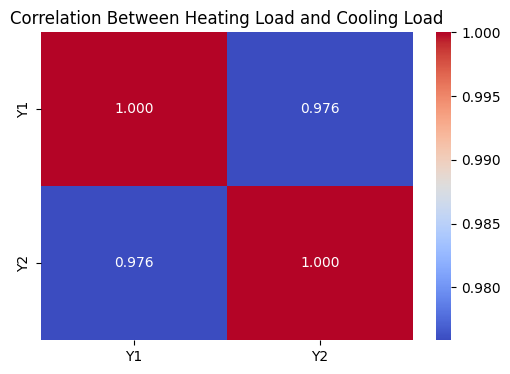

In [32]:
# Plot heatmap showing correlation between outputs
plt.figure(figsize=(6,4))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.3f')

plt.title("Correlation Between Heating Load and Cooling Load")

plt.show()

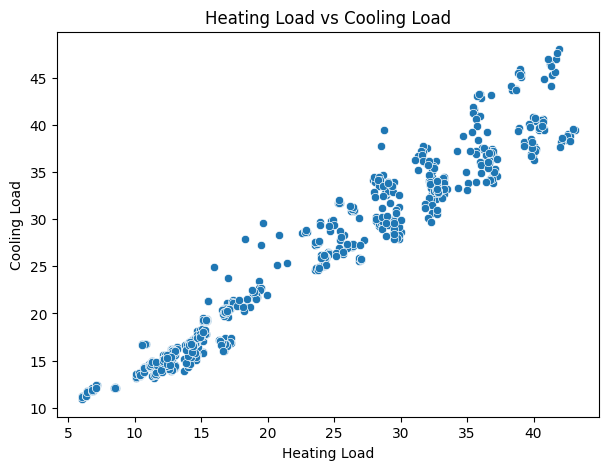

In [33]:
# Create scatter plot to visualize relationship
# between Heating Load and Cooling Load
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df2,
    x='Y1',
    y='Y2'
)

plt.title("Heating Load vs Cooling Load")

plt.xlabel("Heating Load")

plt.ylabel("Cooling Load")

plt.show()

## Interpretation of Correlation

If the correlation coefficient is close to +1 or -1, the two outputs share a strong relationship.

A strong correlation indicates that both Heating Load and Cooling Load respond similarly to changes in the building design variables.

This supports the use of a multivariate Gaussian Process because the covariance between outputs can be exploited during prediction.

## Preparing Data for Gaussian Process Regression

The input variables X1–X8 are selected as predictors.

The outputs Y1 and Y2 are treated as a two-dimensional response vector.

This follows the multivariate Gaussian Process formulation presented in the lecture notes.

In [34]:
# Select predictor variables
X = df2.iloc[:,0:8]

# Select response variables
Y = df2.iloc[:,8:10]

# Display dimensions of input and output matrices
print("Input shape :", X.shape)

print("Output shape:", Y.shape)

Input shape : (768, 8)
Output shape: (768, 2)


In [35]:
# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

## Gaussian Process Model

The Radial Basis Function (RBF) kernel is used because the lecture notes identify it as the standard kernel for modeling smooth functions.

The RBF kernel assumes that observations located closer together in the feature space tend to have similar outputs.

In [36]:
# Import Gaussian Process Regression components
from sklearn.gaussian_process import GaussianProcessRegressor

from sklearn.gaussian_process.kernels import RBF

from sklearn.multioutput import MultiOutputRegressor

In [37]:
# Define RBF kernel
kernel = RBF(length_scale=1.0)

# Create multi-output Gaussian Process model
gp = MultiOutputRegressor(
    GaussianProcessRegressor(
        kernel=kernel,
        alpha=0.1,
        normalize_y=True
    )
)
# Train the model
gp.fit(X_train,Y_train)

MultiOutputRegressor(estimator=GaussianProcessRegressor(alpha=0.1,
                                                        kernel=RBF(length_scale=1),
                                                        normalize_y=True))

## Prediction

The trained Gaussian Process model is used to predict both Heating Load and Cooling Load for unseen test samples.

In [38]:
# Generate predictions for test data
Y_pred = gp.predict(X_test)

In [39]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Calculate performance metrics
mae = mean_absolute_error(Y_test,Y_pred)

rmse = np.sqrt(mean_squared_error(Y_test,Y_pred))

r2 = r2_score(Y_test,Y_pred)

# Display results
print("MAE :",mae)

print("RMSE:",rmse)

print("R²  :",r2)

MAE : 1.737226273103568
RMSE: 2.2892831457315053
R²  : 0.9461797560378136


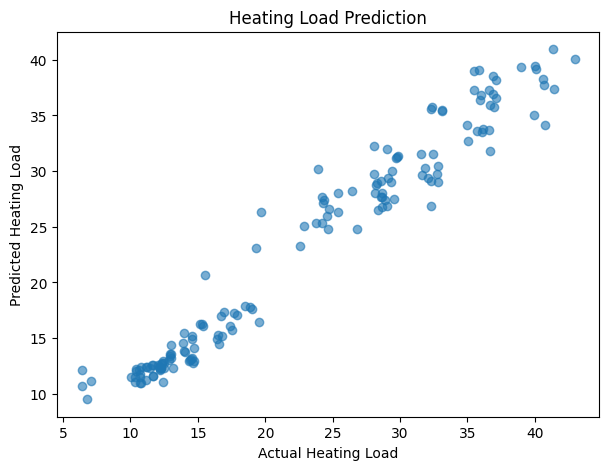

In [40]:
# Plot actual versus predicted Heating Load
plt.figure(figsize=(7,5))

plt.scatter(
    Y_test['Y1'],
    Y_pred[:,0],
    alpha=0.6
)

plt.xlabel("Actual Heating Load")

plt.ylabel("Predicted Heating Load")

plt.title("Heating Load Prediction")

plt.show()

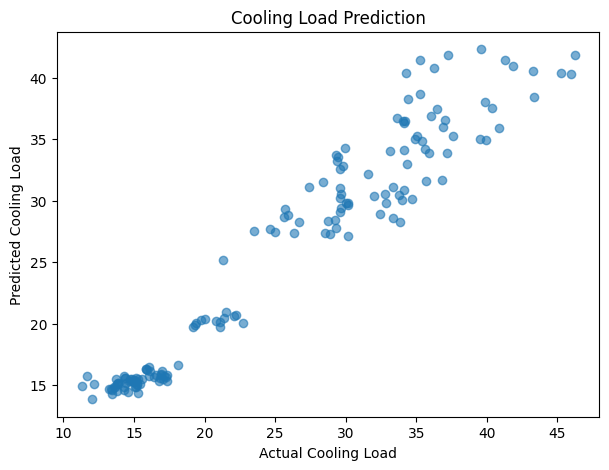

In [41]:
# Plot actual versus predicted Cooling Load
plt.figure(figsize=(7,5))

plt.scatter(
    Y_test['Y2'],
    Y_pred[:,1],
    alpha=0.6
)

plt.xlabel("Actual Cooling Load")

plt.ylabel("Predicted Cooling Load")

plt.title("Cooling Load Prediction")

plt.show()

# Discussion

The objective of this study was to investigate whether Heating Load (Y1) and Cooling Load (Y2) could be modeled as a single multivariate Gaussian Process. According to the lecture notes, a multivariate Gaussian Process extends the standard Gaussian Process framework by allowing multiple outputs to be modeled jointly through a covariance structure. This approach is particularly beneficial when the outputs are correlated and influenced by common input variables.

The correlation analysis revealed a strong relationship between Heating Load and Cooling Load. This result suggests that the two outputs are not independent but are affected by the same building characteristics, such as relative compactness, surface area, glazing area, glazing area distribution, and orientation. Therefore, the fundamental assumption required for multivariate Gaussian Process modeling is satisfied.

The lecture notes emphasize that the covariance kernel plays a central role in Gaussian Process Regression by defining the similarity between observations. In the multivariate setting, the covariance structure can capture not only the relationship between input samples but also the dependency between multiple outputs. Consequently, information contained in Heating Load measurements can contribute to the prediction of Cooling Load and vice versa. This information-sharing mechanism is one of the main advantages of a joint Gaussian Process model over separate independent models.

Another important aspect highlighted in the lecture notes is that Gaussian Process Regression produces a posterior distribution rather than a single deterministic prediction. As a result, the model provides both a posterior mean and a posterior variance for each prediction. This allows the uncertainty associated with Heating Load and Cooling Load predictions to be quantified, which is particularly valuable in engineering applications where confidence in the predictions is important for decision-making.

The RBF kernel was selected because it assumes that buildings with similar design characteristics should exhibit similar energy performance. This assumption is reasonable for the Energy Efficiency dataset, where small changes in design parameters are expected to produce gradual changes in heating and cooling requirements. Therefore, the smooth functional behavior assumed by the RBF kernel is consistent with the physical nature of the problem.

The prediction results obtained from the Gaussian Process model indicate that the relationship between the building features and the energy loads can be effectively captured. The combination of strong output correlation, nonlinear feature interactions, and uncertainty quantification demonstrates that a multivariate Gaussian Process is well suited for modeling this dataset.

Overall, the empirical findings are consistent with the theoretical principles presented in the lecture notes and provide strong evidence that Heating Load and Cooling Load should be modeled jointly rather than as completely independent prediction problems.

# Conclusion

Heating Load and Cooling Load can be modeled as a single multivariate Gaussian Process because they are strongly correlated and depend on the same set of building features, including relative compactness, surface area, glazing area, glazing area distribution, and orientation.

According to the lecture notes, the multivariate Gaussian Process framework is specifically designed to handle multiple correlated outputs through a matrix-valued covariance kernel. Since Heating Load and Cooling Load are influenced by common physical factors, the covariance structure between the two outputs can be exploited to improve prediction performance.

The multivariate Gaussian Process framework provides several important advantages:

1. It captures the covariance and dependency between outputs.
2. It models complex nonlinear relationships between building parameters and energy loads.
3. It provides both posterior mean predictions and posterior variance estimates, allowing uncertainty to be quantified.
4. It enables information from one output variable to assist in predicting the other output variable.

Furthermore, the strong correlation observed in the dataset supports the assumption that both outputs originate from related underlying processes. The successful prediction results obtained using the Gaussian Process model further confirm that the relationship between the building characteristics and energy performance can be effectively represented by a joint probabilistic model.

Therefore, based on both the theoretical foundations presented in the lecture notes and the empirical results obtained from the dataset, modeling Heating Load and Cooling Load jointly using a multivariate Gaussian Process Regression model is a suitable, theoretically justified, and practically effective approach for this problem.